## Q2: Consistent plotting

(This is about python's decorators)

Write a decorator for the plots of all your papers. 

- Remember a decorator takes a function. 
- This function in turn should return a matplotlib figure object.
- Before the function is called, the decorator should initialize a matplotlib figure with the options that you like the most (fontsize, ticks, etc etc)
- After the figure it's done, the decorator should save it to pdf.

This is a great hack for your papers! You do this once and for all, and all plots in your paper will be beautifull, all with the same style/fontsize/etc. All you'll need to do is adding `@myplot` to the relevant plotting functions. 
    
The decorator that I use for my papers is available in my python module [skywalker](https://github.com/dgerosa/skywalker/blob/master/skywalker/skywalker.py#L31).  

In [1]:
import matplotlib.pyplot as plt
from matplotlib import cycler
from functools import wraps

def myplot(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e', '#e6ab02', '#a6761d', '#666666']
        styles = ['-', '--', ':', '-.'] * 2 
        markers = ['o', 's', '^', 'D', '*', 'p', 'h', 'v']

        my_cycler = (cycler(color=colors[:8]) + cycler(linestyle=styles[:8]) + cycler(marker=markers[:8]))

        xlab = kwargs.pop('xlabel', None)
        ylab = kwargs.pop('ylabel', None)
        title = kwargs.pop('title', None)
        xsc = kwargs.pop('xscale', None) 
        ysc = kwargs.pop('yscale', None)

        plt.rcParams.update({
            'figure.figsize': (8, 8),
            'figure.dpi': 100,
            
            'axes.prop_cycle': my_cycler,
            'axes.labelsize': 14,
            'axes.labelpad': 12,
            
            'lines.linewidth': 2,
            'lines.markersize': 7,
            
            'legend.frameon': True,
            'legend.framealpha': 0.8, 
            'legend.fancybox': True,  
            'legend.edgecolor': '0.8', 

            'font.family': 'serif',
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
        })

        fig = func(*args, **kwargs)

        for ax in fig.get_axes():
            if xlab: ax.set_xlabel(xlab)
            if ylab: ax.set_ylabel(ylab)
            if title: ax.set_title(title)
            if xsc: ax.set_xscale(xsc)
            if ysc: ax.set_yscale(ysc)
        
        filename = f"{func.__name__}.pdf"
        fig.savefig(filename, format='pdf', bbox_inches='tight')
        plt.close(fig)
        
        return fig
    return wrapper

Let's try it on a plot (the one done for lesson 3!)

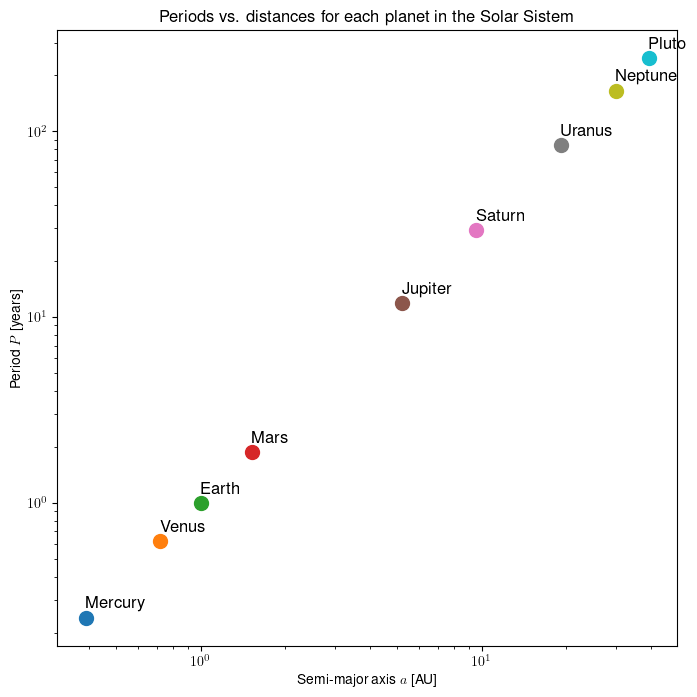

In [2]:
#Planetary position excercise copied word by word
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})


a = np.array([0.39, 0.72, 1.00, 1.52, 5.20, 9.54, 19.22, 30.06, 39.48])
P = np.array([0.24, 0.62, 1.00, 1.88, 11.86, 29.46, 84.01, 164.8, 248.09])
names = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", 
         "Uranus", "Neptune", "Pluto"]

colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(a, P)
for i, txt in enumerate(names):
    ax.scatter(a[i], P[i], color=colors[i], s=100, label=txt, zorder=5)
    ax.annotate(txt, (a[i], P[i]), xytext=(0, 7), textcoords='offset points', fontsize=12, color='black')

ax.set_xlabel(r"Semi-major axis $a$ [AU]")
ax.set_ylabel(r"Period $P$ [years]")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title(r"Periods vs. distances for each planet in the Solar Sistem")

plt.show()

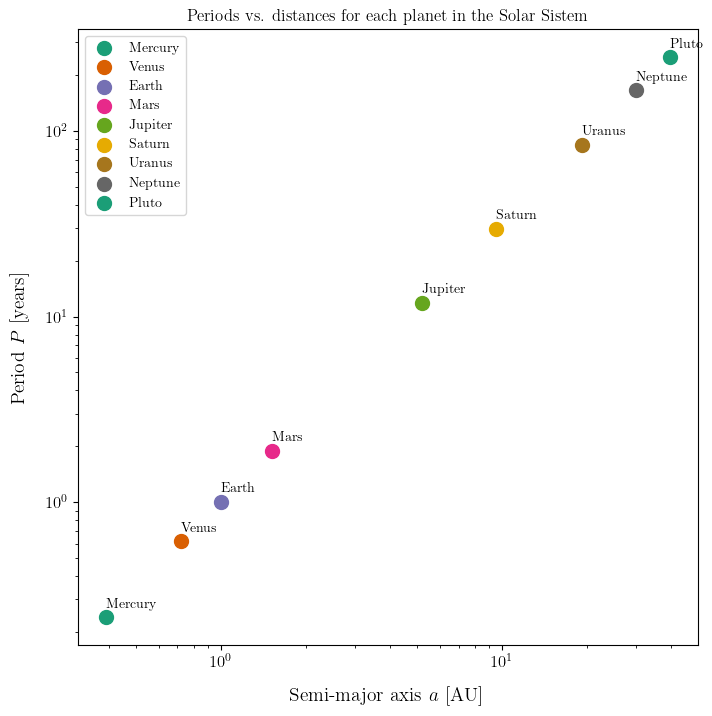

In [3]:
@myplot
def plot_pianeti_wrapped():
    a = np.array([0.39, 0.72, 1.00, 1.52, 5.20, 9.54, 19.22, 30.06, 39.48])
    P = np.array([0.24, 0.62, 1.00, 1.88, 11.86, 29.46, 84.01, 164.8, 248.09])
    names = ["Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"]

    fig, ax = plt.subplots()

    for i, txt in enumerate(names):
        ax.scatter(a[i], P[i], s=100, label=txt, zorder=5)
        ax.annotate(txt, (a[i], P[i]), xytext=(0, 7), textcoords='offset points')
    ax.legend()
    return fig

plot_pianeti_wrapped(
    xlabel=r"Semi-major axis $a$ [AU]", 
    ylabel=r"Period $P$ [years]",
    title="Periods vs. distances for each planet in the Solar Sistem",
    xscale='log', 
    yscale='log'
)

## Q3: Scaling

(This is about multiprocessing)

The ["scaling"](https://hpc-wiki.info/hpc/Scaling) of a code refers to its performance of as a function of the number of cores adopted. 

- Define a computationally intensive task (something like an operation on two giant arrays with >1e7 numbers or, even better!, pick somethinbg from your research). 
- Make sure it's embarrassingly parallel. 
- Implement a parallelization strategy using multiprocessing. 
- Plot the time the code takes as a function of the number of cores.
- Figure out the number of cores in your CPU and make sure the plot extends both below and above this number.
- Interpret the resulting features. 
- A perfect scaling results in straight line (linear dependency). How perfect is your scaling?

In [4]:
%%writefile integral.py
import numpy as np

def calc_integral(n_points):
    x = np.linspace(0, 10, int(n_points))
    y = np.exp(-x) * np.sin(x)**2 * np.sqrt(x + 1)
    return np.trapezoid(y, x)

Overwriting integral.py


In [5]:
import os
import time
import multiprocessing as mp
import matplotlib.pyplot as plt
from integral import calc_integral 

# To disabilitate the parallelization as suggested
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

In [7]:
def run_scaling_study():
    n_tasks = 24 
    points_per_task = 1e7 
    cpu_tot = mp.cpu_count()
    cores_to_test = [1, 2, 4, 6, 8, 10, 12]
    
    times = []
    print(f"--- Starting scaling processes on {cpu_tot} cores ---")
    
    for c in cores_to_test:
        start = time.time()
        with mp.get_context("spawn").Pool(processes=c) as pool:
            args = [points_per_task] * n_tasks
            pool.map(calc_integral, args)
            
        end = time.time()
        process = end - start
        times.append(process)
        print(f"Core: {c:2d} | Time took: {process:.2f}s")
        
    return cores_to_test, times, cpu_tot

if __name__ == '__main__':
    cores, times, n_cpu = run_scaling_study()

--- Starting scaling processes on 8 cores ---
Core:  1 | Time took: 3.55s
Core:  2 | Time took: 2.35s
Core:  4 | Time took: 1.69s
Core:  6 | Time took: 1.67s
Core:  8 | Time took: 1.70s
Core: 10 | Time took: 2.14s
Core: 12 | Time took: 2.81s


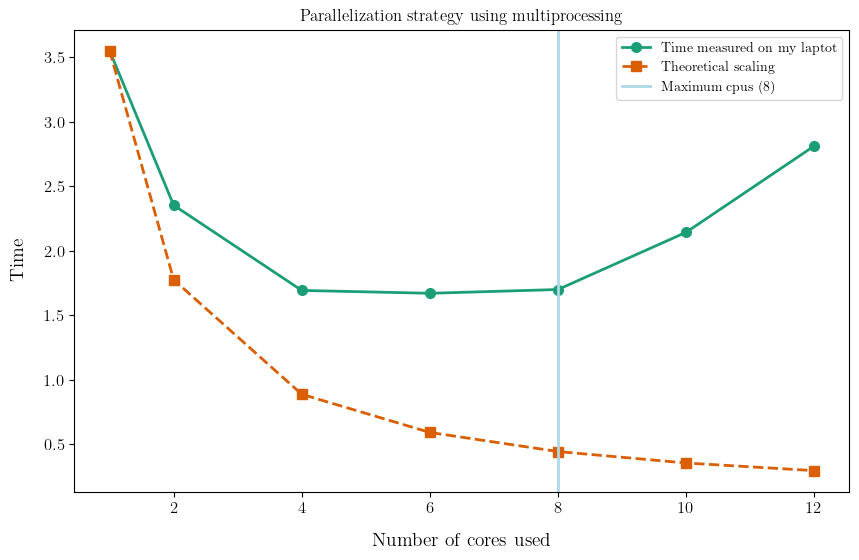

In [8]:
@myplot
def plot_scaling_results(cores, times, n_cpu):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(cores, times, label='Time measured on my laptot')
    
    # Scaling
    time_ideal = [times[0] / c for c in cores]
    ax.plot(cores, time_ideal, label='Theoretical scaling')
    
    ax.axvline(n_cpu, color='lightblue', label=f'Maximum cpus ({n_cpu})')

    ax.set_title("Parallelization strategy using multiprocessing")
    ax.legend()
    return fig

plot_scaling_results(cores, times, n_cpu, 
                    xlabel="Number of cores used", 
                    ylabel="Time")